<a href="https://colab.research.google.com/github/roborew/ComputerVision/blob/main/MASK_RCNN_PyTorch_with_OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import torch
import torch.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision import transforms, models
from pycocotools.coco import COCO
from torch import optim
from PIL import Image, ImageDraw, ImageFont
import cv2
import matplotlib.pyplot as plt
import gdown
import matplotlib.pyplot as plt
import torchvision.transforms as T
import numpy as np
import torch
import pdb
import sys
import gdown


In [ ]:
!git clone https://github.com/bgshih/coco-text.git

fatal: destination path 'coco-text' already exists and is not an empty directory.


In [ ]:
sys.path.append('/content/coco-text')

In [ ]:
import coco_text

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


COCO dataset, takes too long so uploading to drive directly.

In [ ]:
# gdown.download("https://github.com/bgshih/cocotext/releases/download/dl/cocotext.v2.zip", "cocotext.v2.zip")
# !unzip "cocotext.v2.zip" -d /content/data

# gdown.download("http://images.cocodataset.org/zips/train2014.zip", "train2014.zip")
# !unzip "train2014.zip" -d /content/data

Downloading...
From: https://github.com/bgshih/cocotext/releases/download/dl/cocotext.v2.zip
To: /content/cocotext.v2.zip
100%|██████████| 12.2M/12.2M [00:01<00:00, 10.9MB/s]


Archive:  cocotext.v2.zip
  inflating: /content/data/cocotext.v2.json  


Upload an image for using with the model.

In [ ]:
ct = coco_text.COCO_Text('/content/data/cocotext.v2.json')

loading annotations into memory...
0:00:02.197528
creating index...
index created!


/content/drive/MyDrive/DATASETS/COCOTEXT/train2014/COCO_train2014_000000100506.jpg


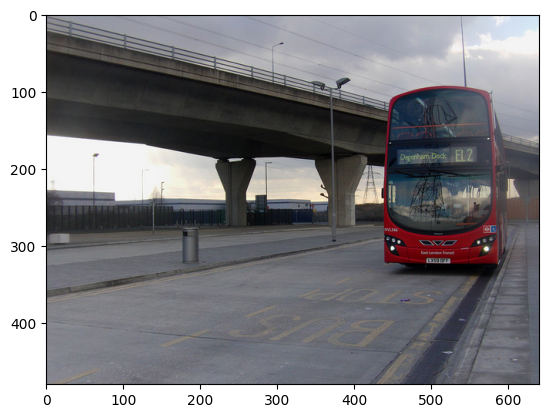

In [ ]:
dataDir='/content/drive/MyDrive/DATASETS/COCOTEXT/train2014/'
imgs = ct.getImgIds(imgIds=ct.train,
                    catIds=[('legibility','legible'),('class','machine printed')])
anns = ct.getAnnIds(imgIds=ct.val,
                        catIds=[('legibility','legible'),('class','machine printed')],
                        areaRng=[0,200])

# get all images containing at least one instance of legible text
imgIds = ct.getImgIds(imgIds=ct.train,
                    catIds=[('legibility','legible')])
# pick one at random
img = ct.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]
I = plt.imread(dataDir + img['file_name'])
print (dataDir + img['file_name'])
plt.figure()
plt.imshow(I)

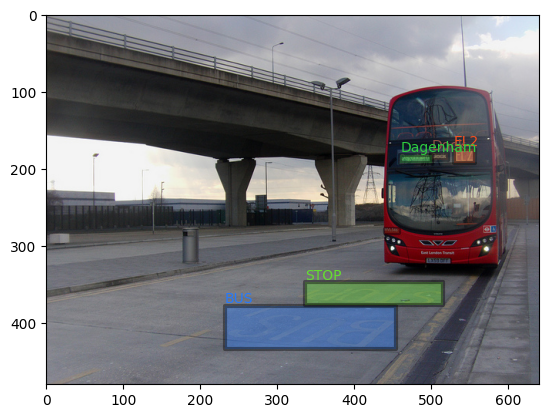

In [ ]:
plt.imshow(I)
annIds = ct.getAnnIds(imgIds=img['id'])
anns = ct.loadAnns(annIds)
anns
ct.showAnns(anns)

https://github.com/bnsreenu/python_for_microscopists/blob/master/286-Object%20detection%20using%20mask%20RCNN%20

Training Mask RCNN with Coco-text

In [ ]:
class COCOTextDataset(Dataset):
    def __init__(self, annotation_file, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform
        self.coco = coco_text.COCO_Text(annotation_file)
        # self.image_ids = self.coco.getImgIds(imgIds=ct.train,
        #             catIds=[('legibility','legible')])
        self.image_ids = self.coco.getImgIds()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(idx)[0]

        img_path = os.path.join(self.root_dir, img_info['file_name'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
         # Convert the image to a PyTorch tensor and normalize it
        image_tensor = torch.from_numpy(image / 255.).permute(2, 0, 1).float()

        # Annotation ids for the current image
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        annotations = self.coco.loadAnns(ann_ids)

        num_objs = len(self.annotations[idx]['annotations'])


        labels = torch.ones((num_objs,), dtype=torch.int64)  # Assuming all instances are 'text'


        if self.transform:
            image = self.transform(image_tensor)

        target = {}
        target["boxes"] = torch.as_tensor([ann['bbox'] for ann in annotations], dtype=torch.float32)
        target["labels"] = torch.ones((len(annotations),), dtype=torch.int64)
        target["masks"] = masks
        target["image_id"] = image_id
        target["area"] = area

        return image, target

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
])

dataset = COCOTextDataset(annotation_file='/content/data/cocotext.v2.json', root_dir='/content/drive/MyDrive/DATASETS/COCOTEXT/train2014', transform=transform)
dataset

loading annotations into memory...
0:00:01.650522
creating index...
index created!


In [ ]:
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=2, shuffle=True, num_workers=2,
    collate_fn=lambda x: tuple(zip(*x)))

In [74]:
weights = weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT
weights.meta["categories"]

['__background__',
 'person',
 'bicycle',
 'car',
 'motorcycle',
 'airplane',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic light',
 'fire hydrant',
 'N/A',
 'stop sign',
 'parking meter',
 'bench',
 'bird',
 'cat',
 'dog',
 'horse',
 'sheep',
 'cow',
 'elephant',
 'bear',
 'zebra',
 'giraffe',
 'N/A',
 'backpack',
 'umbrella',
 'N/A',
 'N/A',
 'handbag',
 'tie',
 'suitcase',
 'frisbee',
 'skis',
 'snowboard',
 'sports ball',
 'kite',
 'baseball bat',
 'baseball glove',
 'skateboard',
 'surfboard',
 'tennis racket',
 'bottle',
 'N/A',
 'wine glass',
 'cup',
 'fork',
 'knife',
 'spoon',
 'bowl',
 'banana',
 'apple',
 'sandwich',
 'orange',
 'broccoli',
 'carrot',
 'hot dog',
 'pizza',
 'donut',
 'cake',
 'chair',
 'couch',
 'potted plant',
 'bed',
 'N/A',
 'dining table',
 'N/A',
 'N/A',
 'toilet',
 'N/A',
 'tv',
 'laptop',
 'mouse',
 'remote',
 'keyboard',
 'cell phone',
 'microwave',
 'oven',
 'toaster',
 'sink',
 'refrigerator',
 'N/A',
 'book',
 'clock',
 'vase',
 'scissors',
 'ted

In [ ]:
def get_model_instance_segmentation(num_classes):
    # Load an instance segmentation model pre-trained on COCO
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one (number of classes is user-defined)
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Now do the same for the mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256  # This is a default value
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask,
                                                       hidden_layer,
                                                       num_classes)

    return model

In [75]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = get_model_instance_segmentation(2)
model.to(device)
model.eval()
print(model)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:


# Choose an optimizer
optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    for images, targets in data_loader:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    print(f"Epoch {epoch}: Loss {losses.item()}")

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


KeyError: Caught KeyError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/worker.py", line 308, in _worker_loop
    data = fetcher.fetch(index)
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/fetch.py", line 51, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/fetch.py", line 51, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "<ipython-input-56-95b1f89b8b1f>", line 16, in __getitem__
    img_info = self.coco.loadImgs(idx)[0]
  File "/content/coco-text/coco_text.py", line 168, in loadImgs
    return [self.imgs[ids]]
KeyError: 7548


In [ ]:

# uploaded = files.upload()

# img_path = next(iter(uploaded))  # This gets the name of the first (and possibly only) uploaded file
# # Read and display the image
# img = plt.imread(img_path)
# plt.imshow(img)
# plt.axis('off')  # Optional: to not show axes for a cleaner image
# plt.show()

In [ ]:


# Predict and visualize
with torch.no_grad():
    predictions = model(image_tensor)

# Extract the bounding boxes, labels, and scores
boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

# Convert the image tensor back to a PIL image for easier manipulation
image_np = image_tensor.squeeze().cpu().numpy()
image_np = np.transpose(image_np, (1, 2, 0))  # Change from (C, H, W) to (H, W, C)
image_np = (image_np * 255).astype(np.uint8)  # Scale back to [0-255] from [0-1]
image_pil = Image.fromarray(image_np)

CONFIDENCE_THRESHOLD = 0.7 # @param {type:"slider", min:0, max:1, step:0.1}

font_size = 100
font_path = '/usr/share/fonts/truetype/humor-sans/Humor-Sans.ttf'
font = ImageFont.truetype(font_path, font_size)

# Draw the bounding boxes and labels on the image
draw = ImageDraw.Draw(image_pil)
for box, label, score in zip(boxes, labels, scores):
    if score > CONFIDENCE_THRESHOLD:  # Only consider detections with a confidence score above a threshold (e.g., 50%)
        box = box.cpu().numpy()
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label]
        color = class_colors.get(class_name, 'white')

        # Draw the box
        draw.rectangle([(box[0], box[1]), (box[2], box[3])], outline=color, width=3)

        # Annotate the box with the class name
        draw.text((box[0], box[1]), f"{class_name}: {score:.2f}", fill=color, font=font)

# Display the image with bounding boxes and labels
image_pil.show()
plt.axis('off')  # Optional: to not show axes for a cleaner image
# Convert back to BGR for OpenCV
plt.imshow(image_pil)